In [17]:
from sklearn import svm
from sklearn import metrics
from sklearn import datasets
from sklearn import model_selection
import matplotlib.pyplot as plt
import numpy as np
import os

# TF_CPP_MIN_LOG_LEVEL: 환경 변수를 사용하여 로깅을 제어(기본값은 0으로 모든 로그가 표시되며,
# INFO 로그를 필터링하려면 1, WARING 로그를 필터링하려면 2, ERROR 로그를 추가로 필터링하려면 3으로 설정)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [18]:
iris = datasets.load_iris()

# model_selection 패키지의 train_test_split 함수를 사용
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris.data,
    iris.target,
    test_size=0.6,
    random_state=42)

In [19]:
# kernel='linear': 데이터를 선형으로 분류하겠다는 설정
# C=1.0: 오차를 어느 정도 허용할지 결정하는 규제 매개변수(클수록 엄격)
# gamma=0.5: 결정 경계의 유연함을 결정(여기서는 linear 커널이라 큰 영향은 없음)
svm = svm.SVC(kernel='linear', C=1.0, gamma=0.5)
svm.fit(X_train, y_train)
predictions = svm.predict(X_test)
score = metrics.accuracy_score(y_test, predictions)
print('정확도: {0:f}'.format(score))

정확도: 0.988889


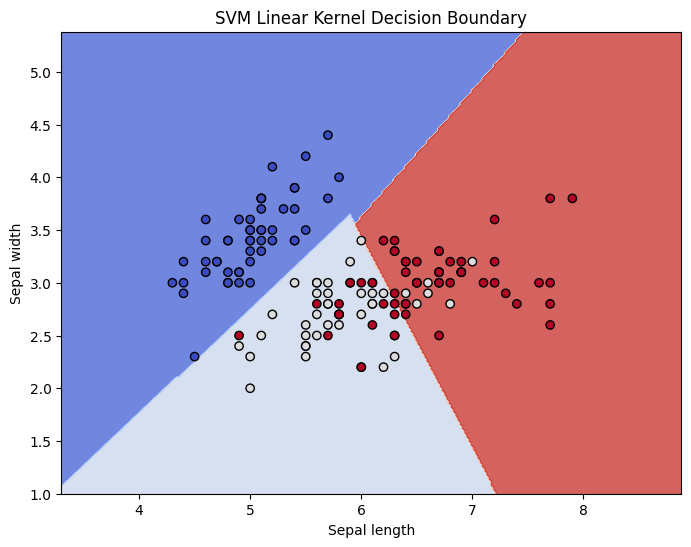

In [22]:
# 2개의 특성(꽃받침 길이, 너비)만 사용
X = iris.data[:, :2]
y = iris.target

# 모델 생성 및 학습 (데이터의 차원 개수가 달라져서 재학습)
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X, y)

# 그래프를 그릴 범위를 설정합니다.
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 결정 경계를 색칠합니다.
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# 실제 데이터 포인트를 점으로 찍습니다.
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('SVM Linear Kernel Decision Boundary')
plt.show()